# Stage 6 — librosa features → context + audio models

Extract librosa descriptors from the downloaded mp3s (Stage 5 output) and run the
Model-B residual test on them, head-to-head against the 10 Spotify features on the
**same rows**, to answer the Stage-6 question: *does an audio model that speaks
librosa lose anything versus one that speaks Spotify's engineered features?*

Everything is evaluated **out-of-fold, grouped by artist**, with fame **and genre**
removed first (CLAUDE.md Stage-3 guards).

In [1]:
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, r2_score

warnings.filterwarnings("ignore")

# Find repo root (folder containing model/) and reuse the SAME helpers and feature
# definitions the pipeline uses, so the notebook cannot drift from train.py.
ROOT = Path.cwd()
while not (ROOT / "model").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from model.train import make_oof_predictions, DEFAULT_LGBM_PARAMS, GROUP_COLUMN, TARGET
from model.features import (
    CONTEXT_FEATURES, CONTEXT_NUMERIC_FEATURES, CONTEXT_CATEGORICAL_FEATURES,
    LIBROSA_FEATURES,
    SPOTIFY_AUDIO_FEATURES, SPOTIFY_AUDIO_NUMERIC_FEATURES, SPOTIFY_AUDIO_CATEGORICAL_FEATURES,
)
# The extractor lives in model/audio.py — the SAME function the serving backend
# calls on an uploaded mp3. One extractor, two callers: a notebook-local copy would
# let training and serving drift apart silently (train/serve skew).
from model.audio import extract_librosa_features

AUDIO_DIR = ROOT / "data" / "audio"
MANIFEST = AUDIO_DIR / "manifest.csv"
FEATURES_CACHE = AUDIO_DIR / "librosa_features.parquet"
ID_COL = "spotify_track_id"
N_SPLITS = 5


## 1. Feature extraction — incremental + parallel

The descriptors (rhythm, energy/dynamics, spectral shape, 13 MFCC means, tonal
spread) are computed by **`model/audio.py::extract_librosa_features`** — the same
function the backend runs on an uploaded mp3. See that file for the per-feature
rationale.

Extraction is:
- **incremental** — only tracks missing from the cache are processed, so repeated
  or growing downloads just extend it;
- **parallel** — one worker process per core (librosa is CPU-bound), in chunks
  **flushed to the cache as they finish**, so a multi-hour run is crash-safe:
  interrupt it anytime and re-run to resume.

In [2]:
N_JOBS = max(1, (os.cpu_count() or 4) - 2)   # leave 2 cores of headroom
CHUNK = 200                                   # cache flush interval (crash-safety)

def extract_one(tid, path):
    # Worker: must never raise (an exception would abort the whole batch);
    # returns (id, features | None, error | None) and we sort it out here.
    try:
        return tid, extract_librosa_features(path), None
    except Exception as e:
        return tid, None, f"{type(e).__name__}: {e}"


In [3]:
manifest = pd.read_csv(MANIFEST)
have_audio = manifest[manifest["audio_path"].notna()].reset_index(drop=True)

if FEATURES_CACHE.exists():
    lib = pd.read_parquet(FEATURES_CACHE)
else:
    lib = pd.DataFrame(columns=[ID_COL])

# Schema guard. The cache is keyed by track id ALONE, so when the extractor's
# feature set changes (richer descriptors, a different analysis window) rows cached
# under the old schema would be silently kept and skipped — you would train on a
# mix of two feature sets, or on nothing at all. Add missing columns as NaN and
# treat any incomplete row as "not yet extracted".
for col in LIBROSA_FEATURES:
    if col not in lib.columns:
        lib[col] = np.nan
stale = lib[LIBROSA_FEATURES].isna().any(axis=1) if len(lib) else pd.Series(dtype=bool)
if len(lib) and stale.any():
    print(f"schema changed: {int(stale.sum())} cached rows predate the current "
          f"{len(LIBROSA_FEATURES)}-feature extractor -> re-extracting them")
fresh_ids = set(lib.loc[~stale, ID_COL]) if len(lib) else set()

todo = have_audio[~have_audio[ID_COL].isin(fresh_ids)].reset_index(drop=True)
print(f"cached (current schema): {len(fresh_ids)} | to extract: {len(todo)} | workers: {N_JOBS}")

n_failed = 0
for start in range(0, len(todo), CHUNK):
    batch = todo.iloc[start:start + CHUNK]
    results = Parallel(n_jobs=N_JOBS)(
        delayed(extract_one)(r[ID_COL], str(ROOT / r["audio_path"]))
        for _, r in batch.iterrows()
    )
    new_rows = []
    for tid, feats, err in results:
        if err:
            n_failed += 1
            print("  FAILED", tid, "->", err)
        else:
            feats[ID_COL] = tid
            new_rows.append(feats)
    if new_rows:                # flush every chunk: a crash at track 8k loses nothing
        lib = pd.concat([lib, pd.DataFrame(new_rows)], ignore_index=True)
        lib = lib.drop_duplicates(ID_COL, keep="last").reset_index(drop=True)
        lib.to_parquet(FEATURES_CACHE, index=False)
    print(f"  {min(start + CHUNK, len(todo))}/{len(todo)} processed | cache {lib.shape[0]} | failed {n_failed}")

print(f"{len(LIBROSA_FEATURES)} librosa features per track")

schema changed: 42 cached rows predate the current 58-feature extractor -> re-extracting them
cached (current schema): 8972 | to extract: 5137 | workers: 6
  200/5137 processed | cache 9214 | failed 0
  400/5137 processed | cache 9414 | failed 0
  600/5137 processed | cache 9614 | failed 0
  800/5137 processed | cache 9814 | failed 0
  1000/5137 processed | cache 10014 | failed 0


/opt/anaconda3/envs/ml/lib/python3.14/site-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


  1200/5137 processed | cache 10214 | failed 0
  1400/5137 processed | cache 10414 | failed 0
  1600/5137 processed | cache 10614 | failed 0
  1800/5137 processed | cache 10814 | failed 0
  2000/5137 processed | cache 11014 | failed 0
  2200/5137 processed | cache 11214 | failed 0
  2400/5137 processed | cache 11414 | failed 0
  2600/5137 processed | cache 11614 | failed 0
  2800/5137 processed | cache 11814 | failed 0
  3000/5137 processed | cache 12014 | failed 0
  3200/5137 processed | cache 12214 | failed 0
  3400/5137 processed | cache 12414 | failed 0
  3600/5137 processed | cache 12614 | failed 0
  3800/5137 processed | cache 12814 | failed 0
  4000/5137 processed | cache 13014 | failed 0
  4200/5137 processed | cache 13214 | failed 0
  4400/5137 processed | cache 13414 | failed 0
  4600/5137 processed | cache 13614 | failed 0
  4800/5137 processed | cache 13814 | failed 0
  5000/5137 processed | cache 14014 | failed 0
  5137/5137 processed | cache 14151 | failed 0
58 librosa fe

## 2. Assemble the modeling table

In [10]:
# Join librosa features onto the 66k dataset for popularity + fame + genre + artist.
# Dedupe on the Spotify id first: a track can appear under several genres, which
# would otherwise fan each audio row out once per genre.
full = pd.read_parquet(ROOT / "data" / "processed" / "orig_data_with_listeners.parquet")
full = full.drop_duplicates(ID_COL)
df = lib.merge(full, on=ID_COL, how="inner")
df = df.dropna(
    subset=[TARGET, GROUP_COLUMN] + CONTEXT_FEATURES + LIBROSA_FEATURES + SPOTIFY_AUDIO_FEATURES
).reset_index(drop=True)

print(f"rows: {len(df)} | artists: {df[GROUP_COLUMN].nunique()} | genres: {df['track_genre'].nunique()}")
print(f"~{len(df) / df['track_genre'].nunique():.0f} rows per genre")
print(f"popularity {df[TARGET].min()}-{df[TARGET].max()}, mean {df[TARGET].mean():.1f}")

rows: 14107 | artists: 7188 | genres: 114
~124 rows per genre
popularity 0-97, mean 39.2


## 3. Context + audio models (out-of-fold, grouped by artist)

The residual recipe from `train.py`:

1. **Context model** predicts popularity from **fame + genre** (`CONTEXT_FEATURES`).
   Genre *must* be in here. Audio features encode genre (acousticness→classical,
   energy→metal), so if genre is left in the residual the audio model scores by
   re-identifying genre rather than judging the song — §4 measures exactly how much
   that inflates things.
2. **Residual** = popularity − out-of-fold context prediction.
3. **Audio model** predicts that residual — once from **librosa** (25), once from
   the **10 Spotify** features, on the *same rows*, so they are comparable.
4. **Shuffled control** = librosa on a permuted residual = the noise floor.

**Sanity check:** the context model should land near **R² ≈ 0.60**. That known value
is the detector for the guard-3 error — a context R² near 0.17 means genre is
missing and every audio number below is inflated. (The shuffled control cannot
catch this; it tests the machinery, not the choice of confounder.)

In [11]:
def report(name, y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    return {
        "model": name,
        "spearman": spearmanr(y_true, y_pred)[0],
        "r2": r2_score(y_true, y_pred),
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": float(np.sqrt(np.mean((y_true - y_pred) ** 2))),
    }

# 1) Context (fame + genre) -> out-of-fold popularity predictions
context_oof, _ = make_oof_predictions(
    df[CONTEXT_FEATURES], df[TARGET], df[GROUP_COLUMN],
    best_params=DEFAULT_LGBM_PARAMS,
    nfeatures=CONTEXT_NUMERIC_FEATURES, cfeatures=CONTEXT_CATEGORICAL_FEATURES,
    n_splits=N_SPLITS,
)
context_r2 = r2_score(df[TARGET], context_oof)
print(f"context R2 = {context_r2:.4f}   (expect ~0.60)")
assert context_r2 > 0.45, (
    f"context R2 {context_r2:.3f} is far below the expected ~0.60 — genre is probably "
    "missing from CONTEXT_FEATURES. Every audio number below would be inflated."
)

# 2) Out-of-fold residual = the part fame AND genre could not explain
residual = pd.Series(df[TARGET].to_numpy() - context_oof, index=df.index)

Finished fold 1
Finished fold 2
Finished fold 3
Finished fold 4
Finished fold 5
context R2 = 0.6156   (expect ~0.60)


In [12]:
# 3) Audio models on the residual — librosa vs Spotify, identical rows
audio_librosa, _ = make_oof_predictions(
    df[LIBROSA_FEATURES], residual, df[GROUP_COLUMN],
    nfeatures=LIBROSA_FEATURES, cfeatures=[], n_splits=N_SPLITS,
)
audio_spotify, _ = make_oof_predictions(
    df[SPOTIFY_AUDIO_FEATURES], residual, df[GROUP_COLUMN],
    nfeatures=SPOTIFY_AUDIO_NUMERIC_FEATURES,
    cfeatures=SPOTIFY_AUDIO_CATEGORICAL_FEATURES, n_splits=N_SPLITS,
)
# 4) Shuffled control: a permuted target the features provably cannot predict.
rng = np.random.default_rng(667)
residual_shuffled = pd.Series(rng.permutation(residual.to_numpy()), index=df.index)
audio_shuffled, _ = make_oof_predictions(
    df[LIBROSA_FEATURES], residual_shuffled, df[GROUP_COLUMN],
    nfeatures=LIBROSA_FEATURES, cfeatures=[], n_splits=N_SPLITS,
)

final_oof = np.clip(context_oof + audio_librosa, 0, 100)

Finished fold 1
Finished fold 2
Finished fold 3
Finished fold 4
Finished fold 5
Finished fold 1
Finished fold 2
Finished fold 3
Finished fold 4
Finished fold 5
Finished fold 1
Finished fold 2
Finished fold 3
Finished fold 4
Finished fold 5


In [13]:
results = pd.DataFrame([
    report("context (fame + genre)",         df[TARGET], context_oof),
    report("audio residual - librosa (25)",  residual,   audio_librosa),
    report("audio residual - Spotify (10)",  residual,   audio_spotify),
    report("audio residual - shuffled ctrl", residual,   audio_shuffled),
    report("final (context + librosa)",      df[TARGET], final_oof),
]).set_index("model").round(4)
results

,spearman,r2,mae,rmse
model,,,,
context (fame + genre),0.7844,0.6156,7.7398,11.0868
audio residual - librosa (25),0.1276,-0.0074,7.7919,11.1233
audio residual - Spotify (10),0.1248,-0.0058,7.7904,11.1148
audio residual - shuffled ctrl,0.0078,-0.0321,7.9219,11.2589
final (context + librosa),0.7875,0.6133,7.7805,11.1196


## 4. Why genre must be in the context model

This is the trap the Stage-3 guards exist for, measured on this data. Re-run the
*same* audio models against a residual where only **fame** was removed — genre left
in — and watch the "audio signal" balloon. Nothing about the audio model changed;
only what we subtracted first did.

In [14]:
context_fame_only, _ = make_oof_predictions(
    df[CONTEXT_NUMERIC_FEATURES], df[TARGET], df[GROUP_COLUMN],
    best_params=DEFAULT_LGBM_PARAMS,
    nfeatures=CONTEXT_NUMERIC_FEATURES, cfeatures=[], n_splits=N_SPLITS,
)
residual_fame_only = pd.Series(df[TARGET].to_numpy() - context_fame_only, index=df.index)
print(f"context R2, fame only = {r2_score(df[TARGET], context_fame_only):.4f}  "
      f"(vs {context_r2:.4f} with genre)")

inflated_librosa, _ = make_oof_predictions(
    df[LIBROSA_FEATURES], residual_fame_only, df[GROUP_COLUMN],
    nfeatures=LIBROSA_FEATURES, cfeatures=[], n_splits=N_SPLITS,
)
inflated_spotify, _ = make_oof_predictions(
    df[SPOTIFY_AUDIO_FEATURES], residual_fame_only, df[GROUP_COLUMN],
    nfeatures=SPOTIFY_AUDIO_NUMERIC_FEATURES,
    cfeatures=SPOTIFY_AUDIO_CATEGORICAL_FEATURES, n_splits=N_SPLITS,
)

sp = lambda a, b: spearmanr(a, b)[0]
S = {
    "librosa_ok":   sp(residual, audio_librosa),
    "spotify_ok":   sp(residual, audio_spotify),
    "shuffled":     sp(residual, audio_shuffled),
    "librosa_infl": sp(residual_fame_only, inflated_librosa),
    "spotify_infl": sp(residual_fame_only, inflated_spotify),
}
pd.DataFrame({
    "context = fame only (WRONG)":  [S["librosa_infl"], S["spotify_infl"]],
    "context = fame + genre (right)": [S["librosa_ok"], S["spotify_ok"]],
    "share that was genre":         [f"{100*(1-S['librosa_ok']/S['librosa_infl']):.0f}%",
                                     f"{100*(1-S['spotify_ok']/S['spotify_infl']):.0f}%"],
}, index=["librosa", "Spotify (10)"]).round(4)

Finished fold 1
Finished fold 2
Finished fold 3
Finished fold 4
Finished fold 5
context R2, fame only = 0.1668  (vs 0.6156 with genre)
Finished fold 1
Finished fold 2
Finished fold 3
Finished fold 4
Finished fold 5
Finished fold 1
Finished fold 2
Finished fold 3
Finished fold 4
Finished fold 5


,context = fame only (WRONG),context = fame + genre (right),share that was genre
librosa,0.4603,0.1276,72%
Spotify (10),0.4288,0.1248,71%


## 5. Results

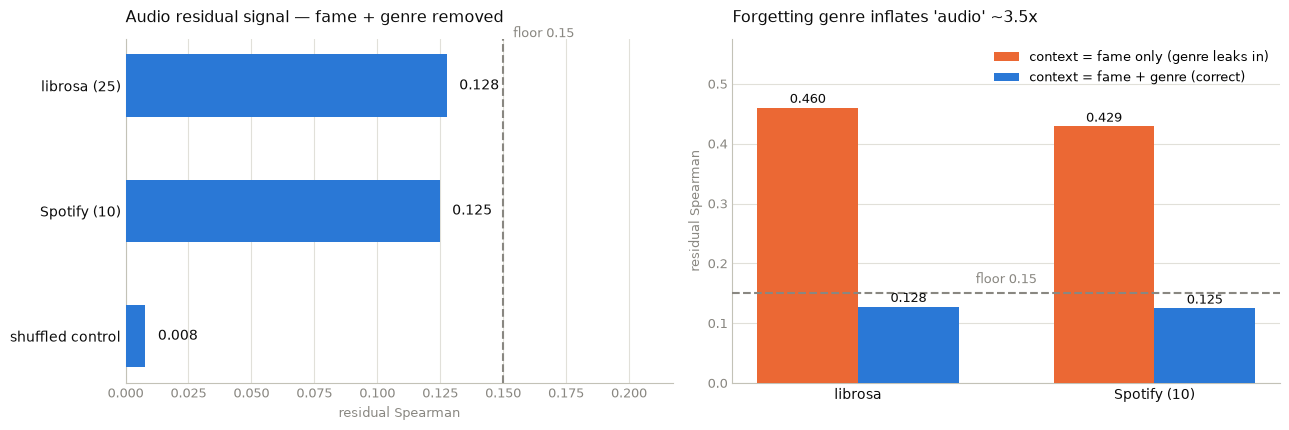

In [15]:
BLUE, ORANGE = "#2a78d6", "#eb6834"     # validated categorical slots 1 & 8
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"
FLOOR = 0.15

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4))

# --- Panel 1: one measure across three models -> ONE hue, identity from labels --
names = ["librosa (25)", "Spotify (10)", "shuffled control"]
vals = [S["librosa_ok"], S["spotify_ok"], S["shuffled"]]
y = np.arange(len(names))[::-1]
ax1.barh(y, vals, height=0.5, color=BLUE, zorder=3)
ax1.axvline(FLOOR, color=MUTED, ls="--", lw=1.5, zorder=4)
ax1.text(FLOOR + 0.004, y.max() + 0.42, f"floor {FLOOR}", color=MUTED, fontsize=9, va="center")
for yi, v in zip(y, vals):
    ax1.text(v + 0.005, yi, f"{v:.3f}", va="center", color=INK, fontsize=10, zorder=5)
ax1.set_yticks(y); ax1.set_yticklabels(names, fontsize=10)
ax1.set_xlim(0, max(max(vals), FLOOR) * 1.45)
ax1.set_xlabel("residual Spearman", color=MUTED, fontsize=9)
ax1.set_title("Audio residual signal — fame + genre removed",
              loc="left", fontsize=11.5, color=INK, pad=12)

# --- Panel 2: two series -> legend required ------------------------------------
labels = ["librosa", "Spotify (10)"]
infl = [S["librosa_infl"], S["spotify_infl"]]
ok = [S["librosa_ok"], S["spotify_ok"]]
x = np.arange(len(labels)); w = 0.34
ax2.bar(x - w/2, infl, w, color=ORANGE, label="context = fame only (genre leaks in)", zorder=3)
ax2.bar(x + w/2, ok,   w, color=BLUE,   label="context = fame + genre (correct)", zorder=3)
ax2.axhline(FLOOR, color=MUTED, ls="--", lw=1.5, zorder=4)
ax2.text(0.5, FLOOR + 0.012, f"floor {FLOOR}", color=MUTED, fontsize=9,
         ha="center", va="bottom", zorder=6)   # the gap between groups is the only clear spot
for xi, v in zip(x - w/2, infl):
    ax2.text(xi, v + 0.008, f"{v:.3f}", ha="center", color=INK, fontsize=9.5, zorder=5)
for xi, v in zip(x + w/2, ok):
    ax2.text(xi, v + 0.008, f"{v:.3f}", ha="center", color=INK, fontsize=9.5, zorder=5)
ax2.set_xticks(x); ax2.set_xticklabels(labels, fontsize=10)
ax2.set_ylim(0, max(infl) * 1.25)
ax2.set_ylabel("residual Spearman", color=MUTED, fontsize=9)
ax2.set_title("Forgetting genre inflates 'audio' ~3.5x", loc="left",
              fontsize=11.5, color=INK, pad=12)
ax2.legend(frameon=False, fontsize=9, loc="upper right")

for ax, axis in ((ax1, "x"), (ax2, "y")):
    ax.grid(axis=axis, color=GRID, lw=0.8, zorder=0)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color("#c3c2b7")
    ax.tick_params(colors=MUTED, labelsize=9, length=0)
    ax.tick_params(axis="y" if axis == "x" else "x", labelcolor=INK, labelsize=10)

fig.tight_layout()
plt.show()